# Synthetic Soft-DTW separator demo

This notebook constructs the three synthetic curves, searches for a Soft-DTW separator using the existing solver, and visualizes the learned separator together with the input curves.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from soft_dtw_solver import (
    SoftDTW,
    optimize_ball_robust,
    validate_witness_hard_dtw,
    to_1d_numpy,
    hard_dtw_distance,
 )

plt.style.use('seaborn-v0_8-whitegrid')

def curve_color(label):
    if label.lower().startswith('inside'):
        return 'tab:blue'
    return 'tab:red'

def plot_curves(curves, title='Curves', xlabel='Time', ylabel='Value'):
    fig, ax = plt.subplots(figsize=(10, 5))
    for label, curve in curves.items():
        xs = np.linspace(0.0, 1.0, len(curve))
        ax.plot(
            xs,
            curve,
            marker='o',
            linewidth=1,
            markersize=2,
            color=curve_color(label),
            label=label,
        )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Build the synthetic curves

The first two curves are meant to be inside the separator, and the linear curve is the outside example.

In [44]:
k = 15
m = 15
epsilon = 10

x = np.linspace(0.0, 1.0, k)
inside_1 = 1.5 * np.sin(3.0 * np.pi * x)
inside_2 = 1.4 * np.sin(3.0 * np.pi * (x ** 1.2) + 0.12)
inside_3 = 1.2 * np.sin(3.0 * np.pi * (x ** 1.2) + 1.5)
outside_1 = 0.4 * np.cos(3.0 * np.pi * x**2)
outside_2 = 0.5 * np.cos(3.0 * np.pi * x**2- 0.3)
curves = {
    'inside 1': inside_1,
    'inside 2:': inside_2,
    'inside 3:': inside_3,
    'outside 1:': outside_1,
    'outside 2:': outside_2,
}

labels = list(curves.keys())
Qs = [curves[label] for label in labels]
inside_indices = [0, 1]

print(f'k={k}, m={m}, epsilon={epsilon}')
for label, curve in curves.items():
    print(label, np.round(curve, 4))

k=15, m=15, epsilon=10
inside 1 [ 0.      0.9352  1.4624  1.3515  0.6508 -0.3338 -1.1727 -1.5    -1.1727
 -0.3338  0.6508  1.3515  1.4624  0.9352  0.    ]
inside 2: [ 0.1676  0.6921  1.2019  1.3992  1.1186  0.3896 -0.5296 -1.2353 -1.3654
 -0.8098  0.1824  1.0908  1.3931  0.8824 -0.1676]
inside 3: [ 1.197   1.1367  0.7996  0.1882 -0.5267 -1.0683 -1.1767 -0.7553  0.0386
  0.8295  1.1978  0.9159  0.1098 -0.7713 -1.197 ]
outside 1: [ 0.4     0.3995  0.3926  0.3631  0.2873  0.1441 -0.0638 -0.2828 -0.3992
 -0.2918  0.0384  0.3576  0.3206 -0.1077 -0.4   ]
outside 2: [ 0.4777  0.4842  0.4971  0.4956  0.4459  0.31    0.0696 -0.2333 -0.4672
 -0.4495 -0.1012  0.3608  0.4712  0.0138 -0.4777]


## Plot the input curves

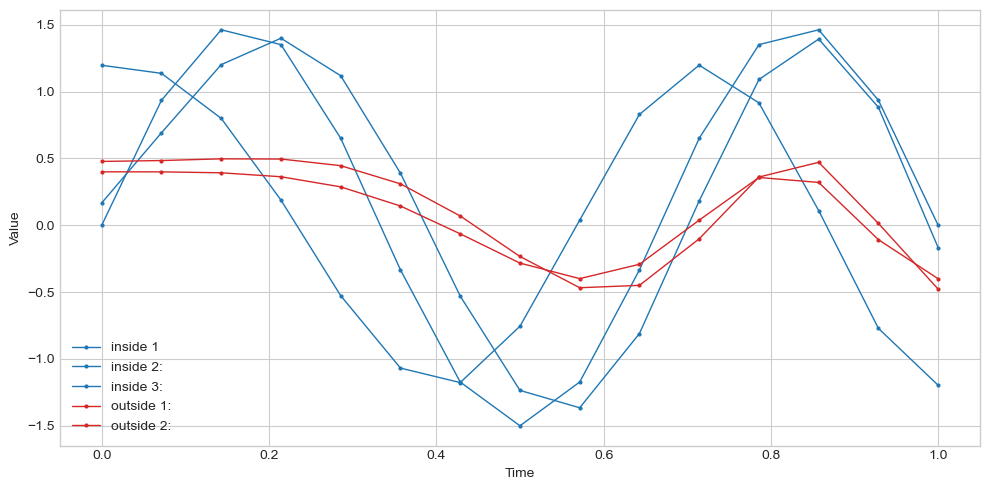

In [45]:
plot_curves(curves, title='')

## Run the separator search

This uses `optimize_ball_robust()` to find a Soft-DTW center that keeps the two sine-like curves inside and the linear curve outside.

In [31]:
gamma = 0.1
epochs = 1500
retries = 10

success, P_opt, Delta_opt, max_in, min_out, hard_valid = optimize_ball_robust(
    Qs=Qs,
    I=inside_indices,
    k=k,
    gamma=gamma,
    epochs=epochs,
    retries=retries,
    require_hard_dtw_validation=True,
    verbose=False,
 )

if not success:
    raise RuntimeError('No separator was found with the current solver settings.')

sdtw = SoftDTW(gamma=gamma)
soft_dists = [float(sdtw(torch.tensor(q, dtype=torch.float32), P_opt).item()) for q in Qs]
hard_dists = [hard_dtw_distance(P_opt, q) for q in Qs]

result_summary = {
    'success': success,
    'hard_valid': hard_valid,
    'Delta': float(Delta_opt.item()) if hasattr(Delta_opt, 'item') else float(Delta_opt),
    'max_in_hard_dtw': max_in,
    'min_out_hard_dtw': min_out,
    'soft_distances': dict(zip(labels, soft_dists)),
    'hard_distances': dict(zip(labels, hard_dists)),
}

result_summary

{'success': True,
 'hard_valid': True,
 'Delta': 1.0,
 'max_in_hard_dtw': 0.49245853967952147,
 'min_out_hard_dtw': 3.8012713225883314,
 'soft_distances': {'inside 1: base sine': 0.04790395870804787,
  'inside 2: warped + scaled sine': 0.02092277817428112,
  'inside 3: warped + scaled + shifted sine': 3.2488040924072266,
  'outside 1: cosine': 6.416482448577881,
  'outside 2: shifted cosine': 5.191329002380371},
 'hard_distances': {'inside 1: base sine': 0.49245850019449433,
  'inside 2: warped + scaled sine': 0.49245853967952147,
  'inside 3: warped + scaled + shifted sine': 3.8012713225883314,
  'outside 1: cosine': 7.022496386907296,
  'outside 2: shifted cosine': 5.751217130634723}}

## Plot the separator against the curves

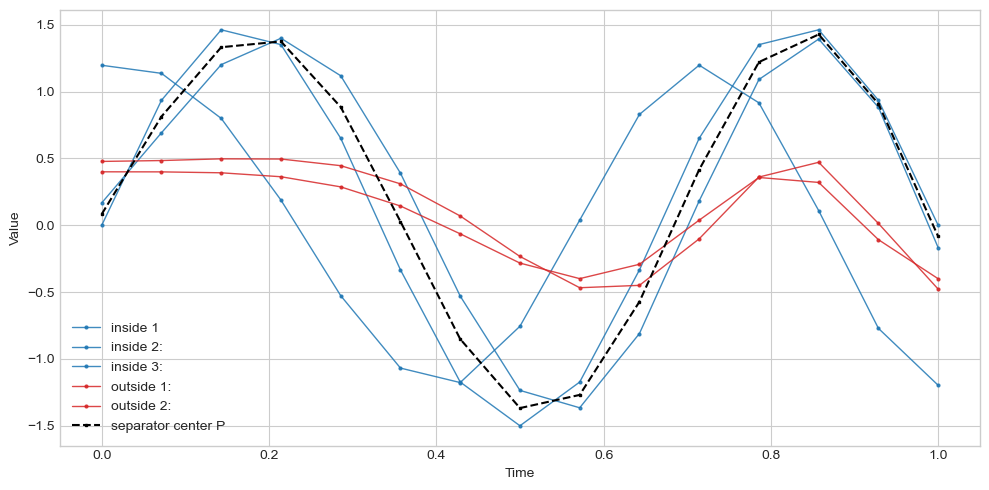

In [46]:
separator_curve = to_1d_numpy(P_opt)
separator_x = np.linspace(0.0, 1.0, len(separator_curve))

fig, ax = plt.subplots(figsize=(10, 5))
for label, curve in curves.items():
    xs = np.linspace(0.0, 1.0, len(curve))
    ax.plot(
        xs,
        curve,
        marker='o',
        linewidth=1,
        markersize=2,
        alpha=0.85,
        color=curve_color(label),
        label=label,
    )

ax.plot(
    separator_x,
    separator_curve,
    color='black',
    linewidth=1.5,
    markersize=2,
    linestyle='--',
    marker='s',
    label='separator center P',
)

#ax.set_title('Synthetic curves with learned Soft-DTW separator')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.legend()
plt.tight_layout()
plt.show()

## Inspect separator metrics

In [33]:
valid_again, max_in_check, min_out_check, all_hard_dists = validate_witness_hard_dtw(P_opt, Qs, inside_indices)

metrics_rows = []
for idx, label in enumerate(labels):
    metrics_rows.append({
        'label': label,
        'group': 'inside' if idx in inside_indices else 'outside',
        'soft_dtw_to_P': soft_dists[idx],
        'hard_dtw_to_P': hard_dists[idx],
    })

print('Hard-DTW validation:', valid_again)
print('max_in_hard_dtw =', max_in_check)
print('min_out_hard_dtw =', min_out_check)
print('soft margin =', min(soft_dists[i] for i in range(len(Qs)) if i not in inside_indices) - max(soft_dists[i] for i in inside_indices))
print('hard margin =', min_out_check - max_in_check)
print('\nPer-curve distances:')
for row in metrics_rows:
    print(row)

print('\nSeparator values:')
print(np.round(separator_curve, 4))

Hard-DTW validation: True
max_in_hard_dtw = 0.49245853967952147
min_out_hard_dtw = 3.8012713225883314
soft margin = 3.2009001336991787
hard margin = 3.30881278290881

Per-curve distances:
{'label': 'inside 1: base sine', 'group': 'inside', 'soft_dtw_to_P': 0.04790395870804787, 'hard_dtw_to_P': 0.49245850019449433}
{'label': 'inside 2: warped + scaled sine', 'group': 'inside', 'soft_dtw_to_P': 0.02092277817428112, 'hard_dtw_to_P': 0.49245853967952147}
{'label': 'inside 3: warped + scaled + shifted sine', 'group': 'outside', 'soft_dtw_to_P': 3.2488040924072266, 'hard_dtw_to_P': 3.8012713225883314}
{'label': 'outside 1: cosine', 'group': 'outside', 'soft_dtw_to_P': 6.416482448577881, 'hard_dtw_to_P': 7.022496386907296}
{'label': 'outside 2: shifted cosine', 'group': 'outside', 'soft_dtw_to_P': 5.191329002380371, 'hard_dtw_to_P': 5.751217130634723}

Separator values:
[ 0.0838  0.8137  1.3321  1.3753  0.8847  0.0279 -0.8512 -1.3676 -1.2691
 -0.5718  0.4166  1.2211  1.4278  0.9088 -0.0838]
